Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.
/opt/anaconda3/envs/DogRecSys/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


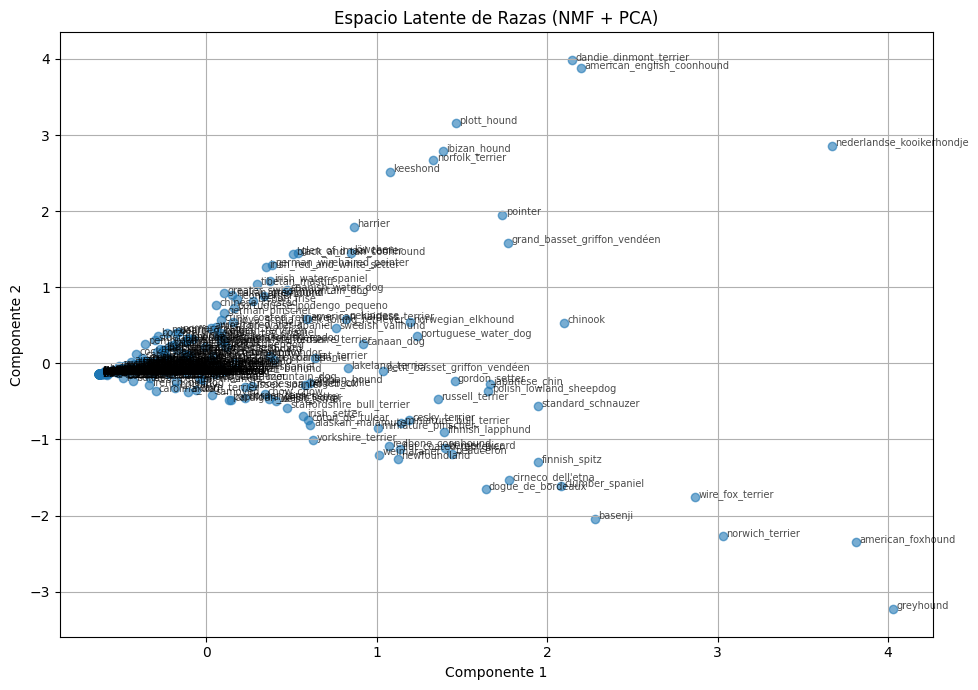

In [1]:
import pandas as pd
from sklearn.decomposition import NMF, PCA
import matplotlib.pyplot as plt

# Recargar la matriz de interacciones subida
ratings_df = pd.read_csv("data/user_dog_ratings.csv", index_col=0)

# Aplicar NMF
nmf_model = NMF(n_components=20, init="random", random_state=42)
W = nmf_model.fit_transform(ratings_df.values)
H = nmf_model.components_

# Reducir H (ítems/razas) con PCA
H_2D = PCA(n_components=2).fit_transform(H.T)

# Crear DataFrame para graficar
df_latent_items = pd.DataFrame(H_2D, columns=["x", "y"])
df_latent_items["breed"] = ratings_df.columns

# Graficar
plt.figure(figsize=(10, 7))
plt.scatter(df_latent_items["x"], df_latent_items["y"], alpha=0.6)
for _, row in df_latent_items.iterrows():
    plt.text(row["x"] + 0.02, row["y"], row["breed"], fontsize=7, alpha=0.7)

plt.title("Espacio Latente de Razas (NMF + PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.tight_layout()
plt.show()

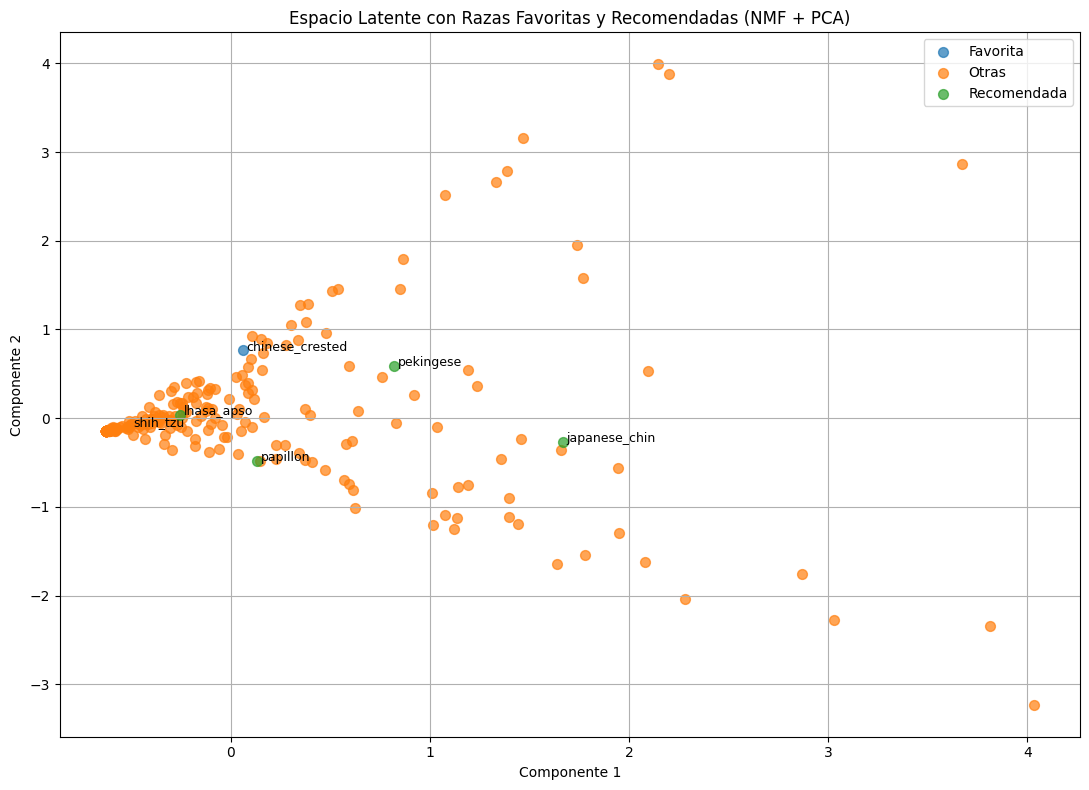

In [2]:
# Definimos razas favoritas del usuario (normalizadas)
razas_favoritas = ["shih_tzu", "chinese_crested"]

# Aseguramos que las razas estén en el DataFrame
highlight_df = df_latent_items.copy()
highlight_df["tipo"] = "otras"
highlight_df.loc[highlight_df["breed"].isin(razas_favoritas), "tipo"] = "favorita"

# Supongamos que estas son las razas recomendadas por NMF
recomendadas_nmf = ["lhasa_apso", "japanese_chin", "papillon", "pekingese", "affenpinscher"]
highlight_df.loc[highlight_df["breed"].isin(recomendadas_nmf), "tipo"] = "recomendada"

# Visualización
plt.figure(figsize=(11, 8))
for tipo, group in highlight_df.groupby("tipo"):
    plt.scatter(group["x"], group["y"], label=tipo.capitalize(), alpha=0.7, s=50)

# Etiquetas solo para favoritas y recomendadas
for _, row in highlight_df[highlight_df["tipo"] != "otras"].iterrows():
    plt.text(row["x"] + 0.02, row["y"], row["breed"], fontsize=9)

plt.title("Espacio Latente con Razas Favoritas y Recomendadas (NMF + PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
